# `maws.space` — surface-aware sampler analysis

End-to-end visual inspection of the surface-aware sampling region. Loads
`data/1BRQ.pdb` (RNase A) and walks through:

1. Ligand geometry (atoms, COM offset).
2. Auto-sized envelopes per shape.
3. Surface rejection in action.
4. Per-shape efficiency.
5. Probe / reach sweeps.
6. Failure mode.
7. Old (20 Å cube) vs new behavior.


## 1. Setup

In [1]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)
from openmm import unit

from maws import space
from maws.complex import Complex
from maws.helpers import center_of_mass, mass_weighted_center, nostrom

# Resolve paths relative to repo root (notebook lives at notebooks/maws/).
os.chdir("../..")

np.random.seed(0)  # reproducibility

PDB_PATH = "data/1BRQ.pdb"

## 2. Build the ligand-only `Complex`

Load `data/1BRQ.pdb` and parameterize with `leaprc.protein.ff19SB`.


In [2]:
ligand_only = Complex(
    force_field_aptamer="leaprc.RNA.OL3",
    force_field_ligand="leaprc.protein.ff19SB",
)
ligand_only.add_chain_from_pdb(
    pdb_path=PDB_PATH,
    force_field_aptamer="leaprc.RNA.OL3",
    force_field_ligand="leaprc.protein.ff19SB",
    parameterized=True,
)
ligand_only.build()

n_atoms = sum(1 for _ in ligand_only.topology.atoms())
print(f"Atoms in ligand: {n_atoms}")

-I: Adding /home/siddharth/miniforge3/envs/maws/dat/leap/prep to search path.
-I: Adding /home/siddharth/miniforge3/envs/maws/dat/leap/lib to search path.
-I: Adding /home/siddharth/miniforge3/envs/maws/dat/leap/parm to search path.
-I: Adding /home/siddharth/miniforge3/envs/maws/dat/leap/cmd to search path.
-f: Source leap.in.

Welcome to LEaP!
(no leaprc in search path)
Sourcing: ./leap.in
----- Source: /home/siddharth/miniforge3/envs/maws/dat/leap/cmd/leaprc.RNA.OL3
----- Source of /home/siddharth/miniforge3/envs/maws/dat/leap/cmd/leaprc.RNA.OL3 done
Log file: ./leap.log
Loading parameters: /home/siddharth/miniforge3/envs/maws/dat/leap/parm/parm10.dat
Reading title:
PARM99 + frcmod.ff99SB + frcmod.parmbsc0 + OL3 for RNA
Loading library: /home/siddharth/miniforge3/envs/maws/dat/leap/lib/RNA.lib
----- Source: /home/siddharth/miniforge3/envs/maws/dat/leap/cmd/leaprc.protein.ff19SB
----- Source of /home/siddharth/miniforge3/envs/maws/dat/leap/cmd/leaprc.protein.ff19SB done
Log file: ./l

Atoms in ligand: 2760


/home/siddharth/miniforge3/envs/maws/lib/python3.11/site-packages/openmm/app/internal/amber_file_parser.py:1165: UserWarning: Non-optimal GB parameters detected for GB model OBC1
  warnings.warn(
/home/siddharth/work/MAWS_2025/maws/complex.py:398: RuntimeWarning: Platform 'CUDA' unavailable: There is no registered Platform called "CUDA"
  self.simulation = self._create_simulation()
/home/siddharth/work/MAWS_2025/maws/complex.py:398: RuntimeWarning: Platform 'OpenCL' unavailable: There is no registered Platform called "OpenCL"
  self.simulation = self._create_simulation()


## 3. Geometric inspection

Plot atoms in 3D, colored by element. Show centroid vs true mass-weighted COM.


In [3]:
positions = np.asarray(nostrom(ligand_only.positions), dtype=float)
masses = np.array(
    [a.element.mass.value_in_unit(unit.dalton) for a in ligand_only.topology.atoms()]
)
elements = [a.element.symbol for a in ligand_only.topology.atoms()]

centroid = center_of_mass(positions)
com_true = mass_weighted_center(positions, masses)
print(f"Centroid:  {centroid}")
print(f"True COM:  {com_true}")
print(f"Offset:    {np.linalg.norm(centroid - com_true):.3f} \u00c5")

dists = np.linalg.norm(positions - com_true, axis=1)
print(
    f"R_min = {dists.min():.2f} \u00c5, R_max = {dists.max():.2f} \u00c5, "
    f"anisotropy = {dists.max() / max(dists.min(), 1e-9):.2f}"
)

Centroid:  [ 20.03377357  46.49850452 -35.82121213]
True COM:  [ 20.10402221  46.59802721 -35.79509779]
Offset:    0.125 Å
R_min = 1.55 Å, R_max = 28.97 Å, anisotropy = 18.63


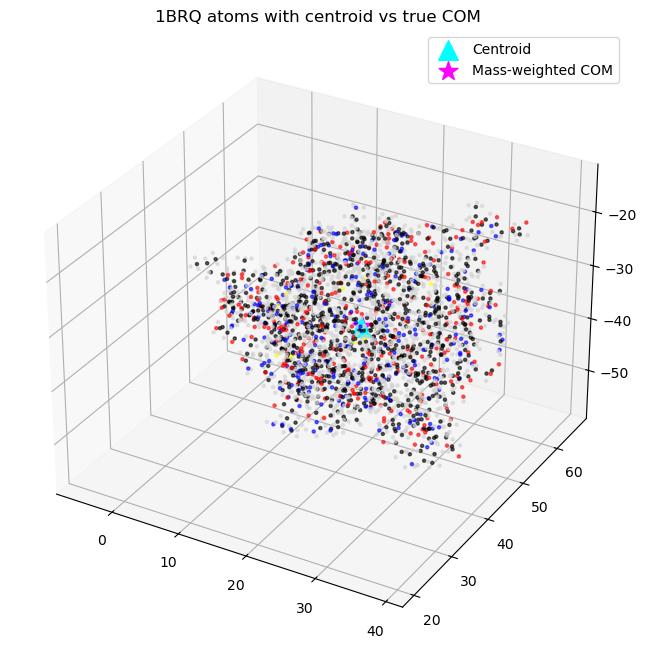

In [4]:
color_map = {
    "H": "lightgray",
    "C": "black",
    "N": "blue",
    "O": "red",
    "S": "yellow",
    "P": "orange",
}
colors = [color_map.get(e, "magenta") for e in elements]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], c=colors, s=5, alpha=0.6)
ax.scatter(*centroid, color="cyan", s=200, marker="^", label="Centroid")
ax.scatter(*com_true, color="magenta", s=200, marker="*", label="Mass-weighted COM")
ax.set_title("1BRQ atoms with centroid vs true COM")
ax.legend()
plt.show()

## 4. Auto-sized envelopes per shape

`compute_envelope_dims` for each shape with reach=10 Å; envelope outline overlaid.


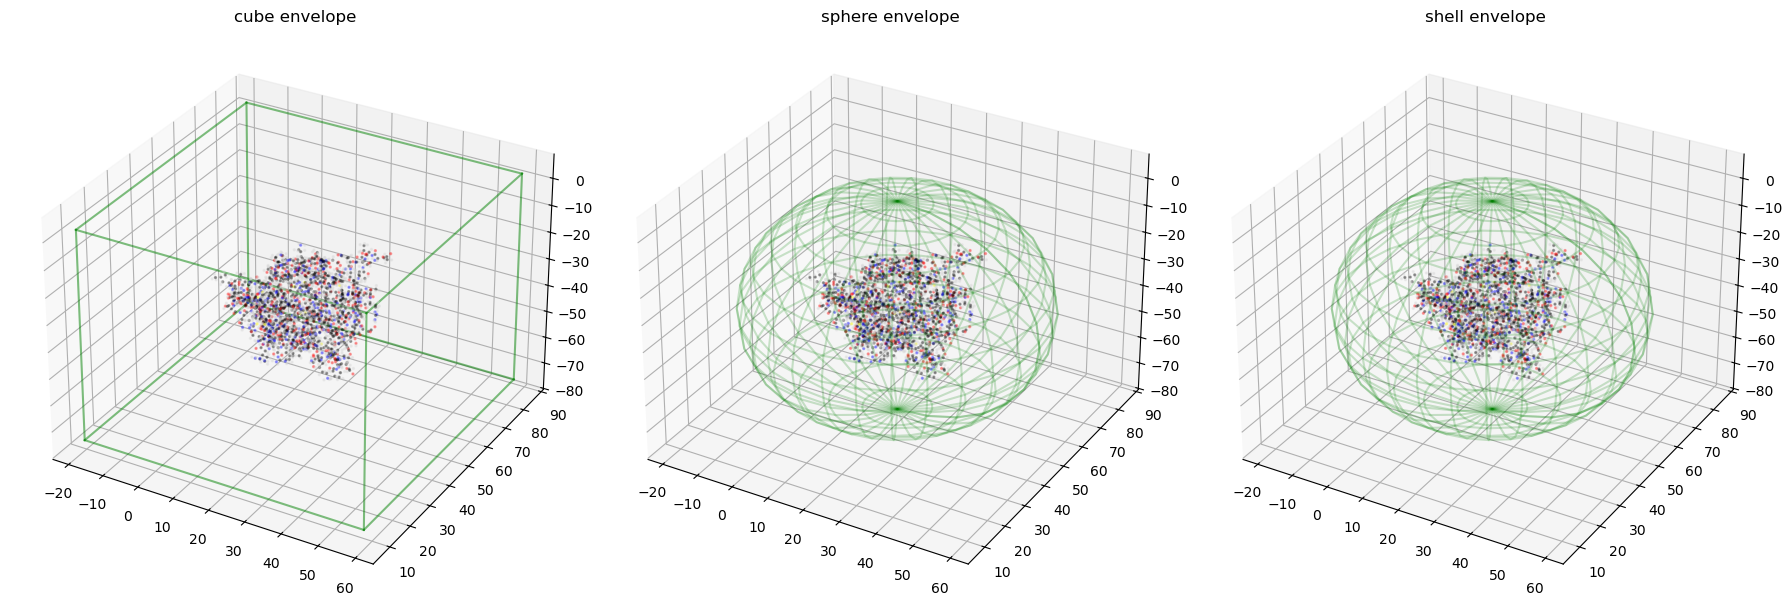

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={"projection": "3d"})

for ax, shape in zip(axes, ["cube", "sphere", "shell"], strict=False):
    dims = space.compute_envelope_dims(ligand_only, shape, reach=10.0)
    ax.scatter(
        positions[:, 0], positions[:, 1], positions[:, 2], c=colors, s=2, alpha=0.3
    )
    ax.set_title(f"{shape} envelope")
    if shape == "cube":
        c = dims["centre"]
        w = dims["width"] / 2
        # draw the 12 cube edges
        corners = [
            (c[0] + sx * w, c[1] + sy * w, c[2] + sz * w)
            for sx in (-1, 1)
            for sy in (-1, 1)
            for sz in (-1, 1)
        ]
        edges = [
            (0, 1),
            (1, 3),
            (3, 2),
            (2, 0),
            (4, 5),
            (5, 7),
            (7, 6),
            (6, 4),
            (0, 4),
            (1, 5),
            (2, 6),
            (3, 7),
        ]
        for a, b in edges:
            xa, ya, za = corners[a]
            xb, yb, zb = corners[b]
            ax.plot([xa, xb], [ya, yb], [za, zb], color="green", alpha=0.5)
    elif shape == "sphere":
        u, v = np.mgrid[0 : 2 * np.pi : 30j, 0 : np.pi : 15j]
        r = dims["radius"]
        c = dims["centre"]
        x = c[0] + r * np.cos(u) * np.sin(v)
        y = c[1] + r * np.sin(u) * np.sin(v)
        z = c[2] + r * np.cos(v)
        ax.plot_wireframe(x, y, z, color="green", alpha=0.2)
    else:  # shell
        c = dims["centre"]
        for r, color in [(dims["inner"], "orange"), (dims["outer"], "green")]:
            if r <= 0:
                continue
            u, v = np.mgrid[0 : 2 * np.pi : 30j, 0 : np.pi : 15j]
            x = c[0] + r * np.cos(u) * np.sin(v)
            y = c[1] + r * np.sin(u) * np.sin(v)
            z = c[2] + r * np.cos(v)
            ax.plot_wireframe(x, y, z, color=color, alpha=0.2)

plt.tight_layout()
plt.show()

## 5. Surface rejection in action

Build an `Excluder` (probe=1.4 Å) and draw 2000 raw envelope samples per shape.
Color accepted (green) vs rejected (red).


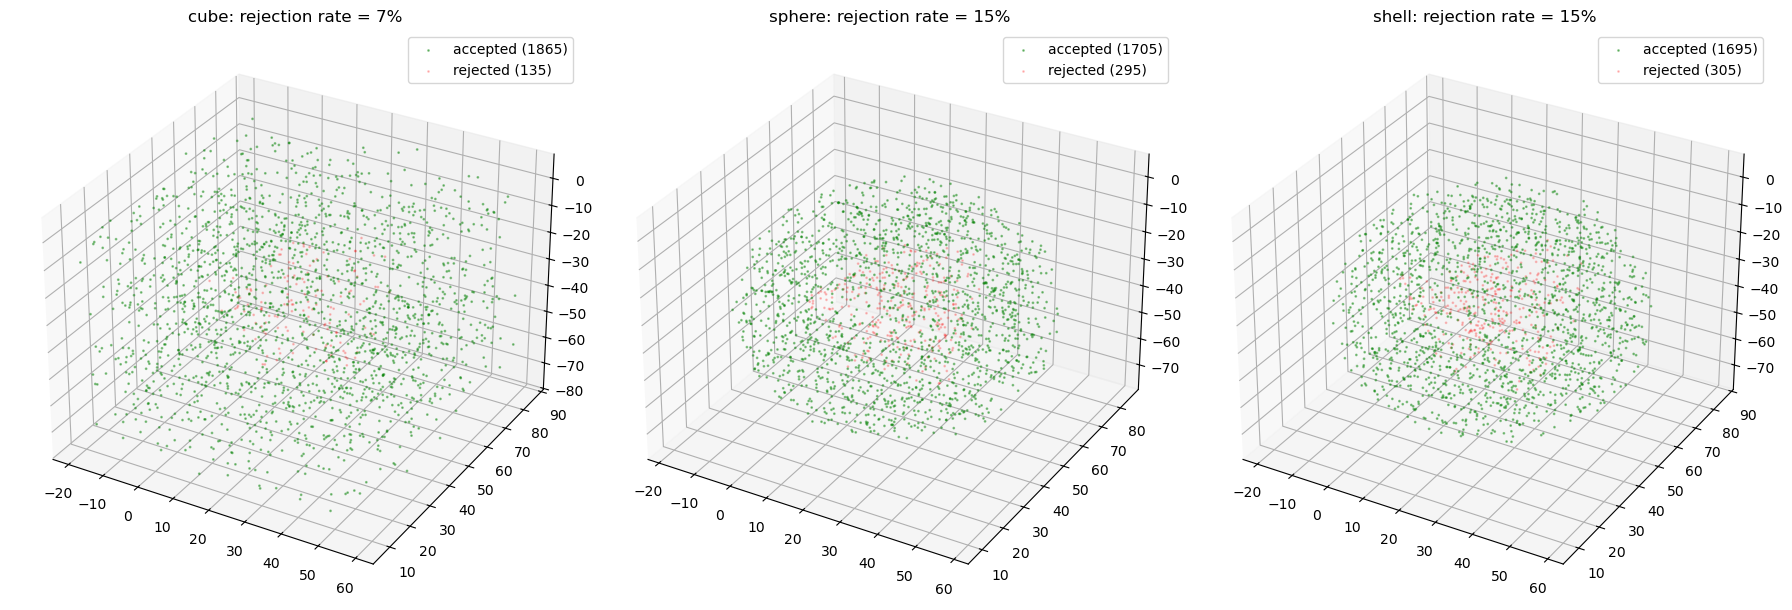

In [6]:
excluder = space.Excluder(ligand_only, probe=1.4)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={"projection": "3d"})
for ax, shape in zip(axes, ["cube", "sphere", "shell"], strict=False):
    dims = space.compute_envelope_dims(ligand_only, shape, reach=10.0)
    cls = {"cube": space.Cube, "sphere": space.Sphere, "shell": space.Shell}[shape]
    envelope = cls(**dims)
    accepted, rejected = [], []
    for _ in range(2000):
        s = envelope.generator()[:3]
        (accepted if excluder.is_clear(s) else rejected).append(s)
    accepted = np.array(accepted) if accepted else np.empty((0, 3))
    rejected = np.array(rejected) if rejected else np.empty((0, 3))
    if len(accepted):
        ax.scatter(
            *accepted.T,
            color="green",
            s=1,
            alpha=0.4,
            label=f"accepted ({len(accepted)})",
        )
    if len(rejected):
        ax.scatter(
            *rejected.T,
            color="red",
            s=1,
            alpha=0.2,
            label=f"rejected ({len(rejected)})",
        )
    ax.set_title(f"{shape}: rejection rate = {len(rejected) / 2000:.0%}")
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Per-shape sampling efficiency

Bar chart: rejection rate by shape (lower = better) and µs per accepted sample.


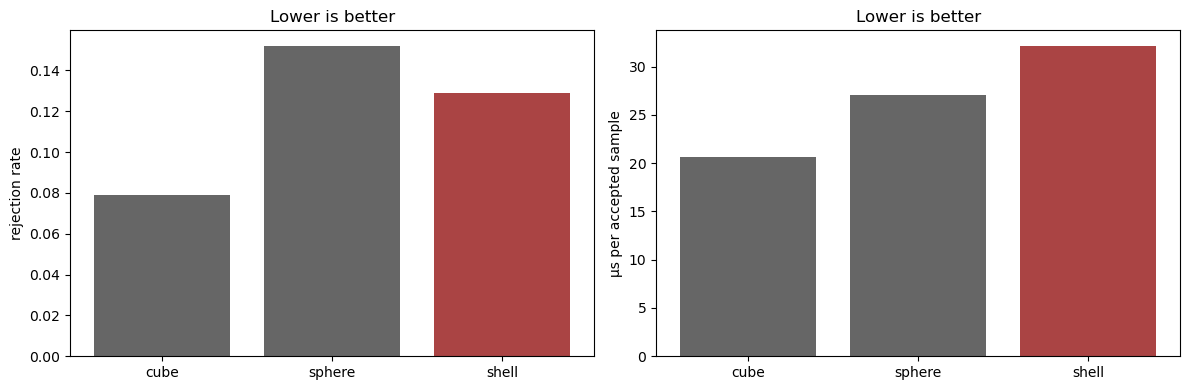

In [7]:
results = {}
for shape in ("cube", "sphere", "shell"):
    sampler = space.make_sampler(shape, ligand_only)
    t0 = time.perf_counter()
    n = 1000
    for _ in range(n):
        sampler.generator()
    dt_us = (time.perf_counter() - t0) / n * 1e6
    dims = space.compute_envelope_dims(ligand_only, shape, 10.0)
    cls = {"cube": space.Cube, "sphere": space.Sphere, "shell": space.Shell}[shape]
    env = cls(**dims)
    rej = (
        sum(1 for _ in range(2000) if not excluder.is_clear(env.generator()[:3])) / 2000
    )
    results[shape] = (rej, dt_us)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(
    results.keys(), [r[0] for r in results.values()], color=["#666", "#666", "#a44"]
)
ax1.set_ylabel("rejection rate")
ax1.set_title("Lower is better")
ax2.bar(
    results.keys(), [r[1] for r in results.values()], color=["#666", "#666", "#a44"]
)
ax2.set_ylabel("\u00b5s per accepted sample")
ax2.set_title("Lower is better")
plt.tight_layout()
plt.show()

## 7. Probe + reach sweeps

How does the accessible region change with `probe` ∈ {0.5, 1.4, 2.5} and
`reach` ∈ {5, 10, 20}? Top row: vary probe; bottom row: vary reach.


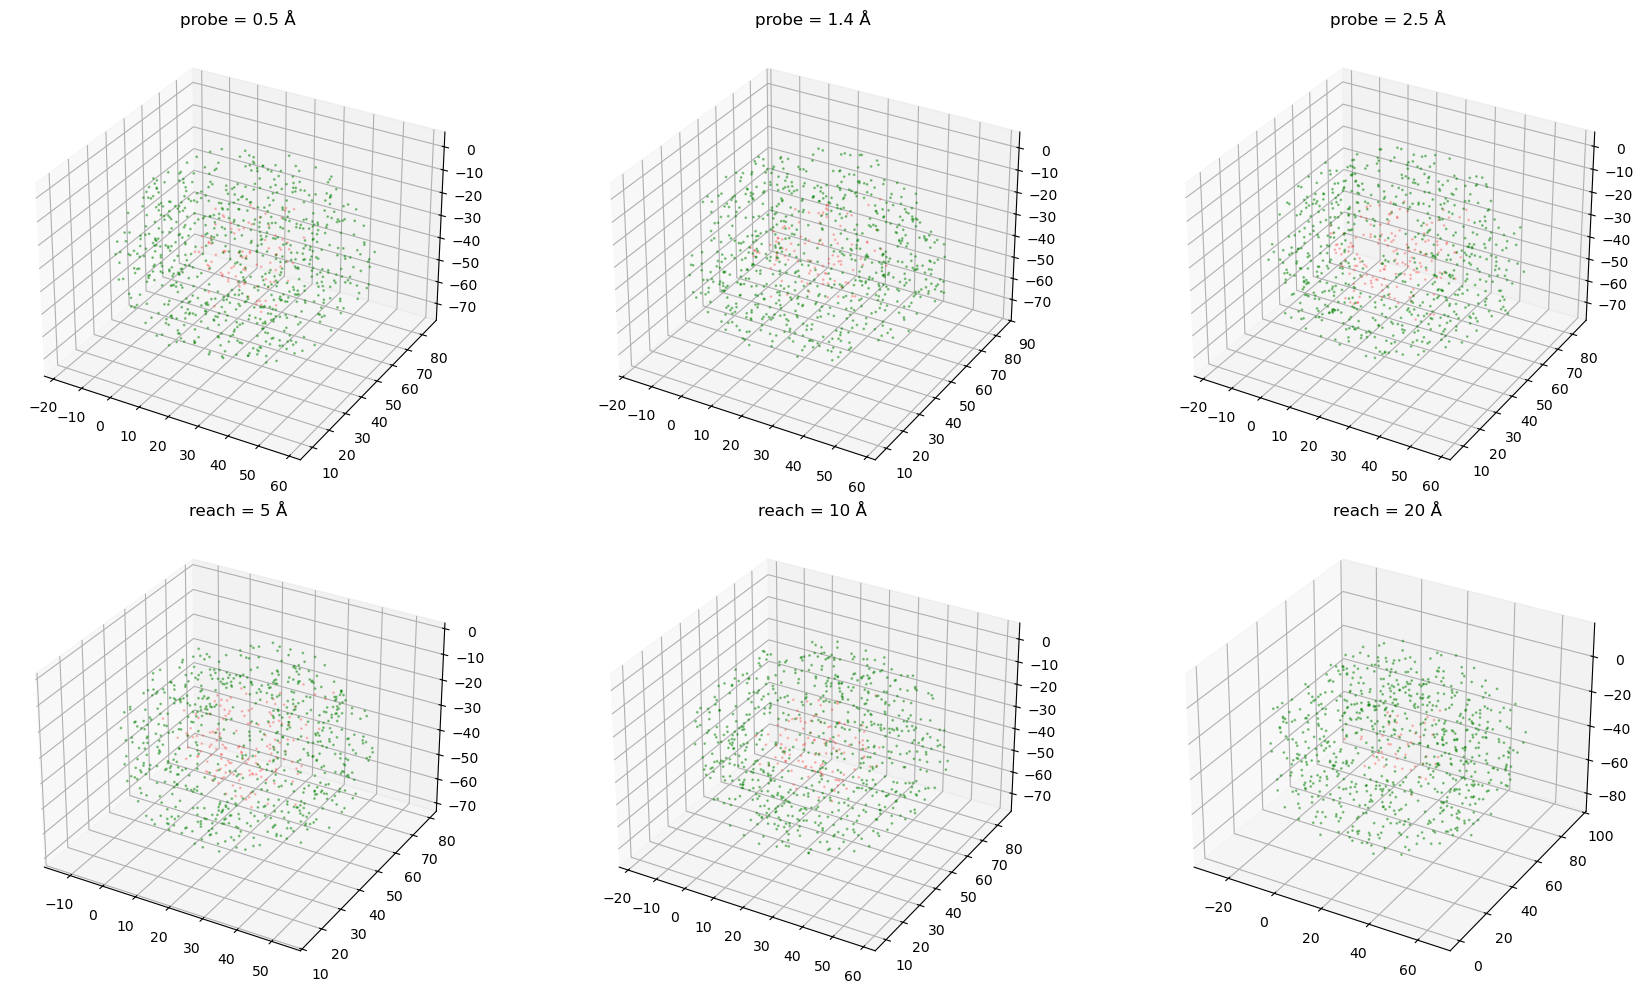

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), subplot_kw={"projection": "3d"})

for j, probe in enumerate((0.5, 1.4, 2.5)):
    ex = space.Excluder(ligand_only, probe=probe)
    sphere = space.Sphere(**space.compute_envelope_dims(ligand_only, "sphere", 10.0))
    pts = np.array([sphere.generator()[:3] for _ in range(800)])
    clear = np.array([ex.is_clear(p) for p in pts])
    ax = axes[0, j]
    ax.scatter(*pts[clear].T, color="green", s=1, alpha=0.4)
    ax.scatter(*pts[~clear].T, color="red", s=1, alpha=0.2)
    ax.set_title(f"probe = {probe} \u00c5")

for j, reach in enumerate((5, 10, 20)):
    ex = space.Excluder(ligand_only, probe=1.4)
    sphere = space.Sphere(**space.compute_envelope_dims(ligand_only, "sphere", reach))
    pts = np.array([sphere.generator()[:3] for _ in range(800)])
    clear = np.array([ex.is_clear(p) for p in pts])
    ax = axes[1, j]
    ax.scatter(*pts[clear].T, color="green", s=1, alpha=0.4)
    ax.scatter(*pts[~clear].T, color="red", s=1, alpha=0.2)
    ax.set_title(f"reach = {reach} \u00c5")

plt.tight_layout()
plt.show()

## 8. Failure mode: fully buried envelope

If the envelope is too small / too deep, no clear point exists. The sampler
should raise `SamplingError` rather than infinite-loop.


In [9]:
buried = space.SurfaceSampler(
    envelope=space.Cube(width=0.1, centre=com_true),
    excluder=excluder,
    max_rejections=20,
)
try:
    buried.generator()
except space.SamplingError as exc:
    print("Caught SamplingError as expected:")
    print(exc)

Caught SamplingError as expected:
Could not draw a clear point in 20 attempts. Envelope may be fully buried - increase --reach, decrease --probe, or check ligand size.


## 9. Old (20 Å cube) vs new behavior

Plot the previous 20 Å cube around the protein next to the new auto-sized
shell + surface rejection. The old default mostly samples the protein
interior; the new default hugs the surface.


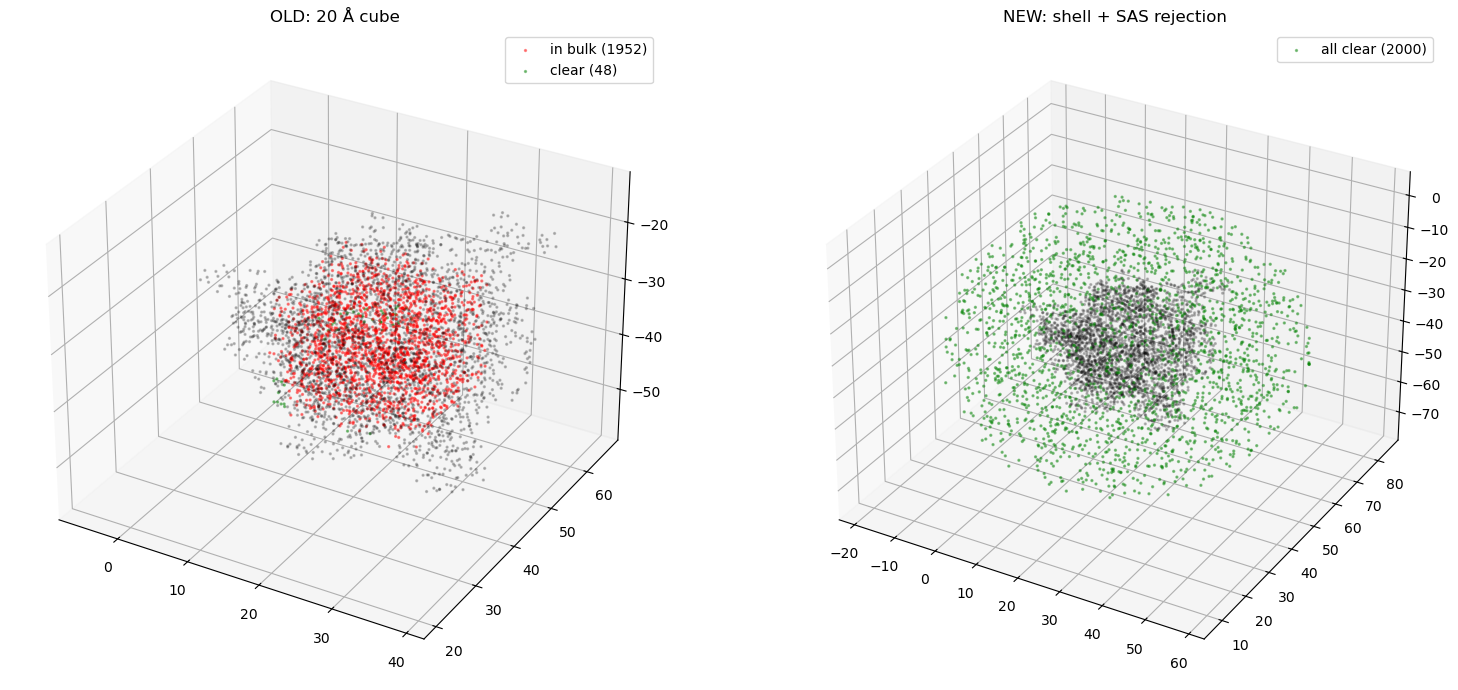

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), subplot_kw={"projection": "3d"})

# Old: 20 Å cube, no rejection
old_cube = space.Cube(width=20.0, centre=com_true)
pts_old = np.array([old_cube.generator()[:3] for _ in range(2000)])
in_protein = np.array([not excluder.is_clear(p) for p in pts_old])
axes[0].scatter(
    positions[:, 0], positions[:, 1], positions[:, 2], color="black", s=2, alpha=0.2
)
axes[0].scatter(
    *pts_old[in_protein].T,
    color="red",
    s=2,
    alpha=0.4,
    label=f"in bulk ({in_protein.sum()})",
)
axes[0].scatter(
    *pts_old[~in_protein].T,
    color="green",
    s=2,
    alpha=0.4,
    label=f"clear ({(~in_protein).sum()})",
)
axes[0].set_title("OLD: 20 \u00c5 cube")
axes[0].legend()

# New: auto-sized shell + rejection
new_sampler = space.make_sampler("shell", ligand_only)
pts_new = np.array([new_sampler.generator()[:3] for _ in range(2000)])
axes[1].scatter(
    positions[:, 0], positions[:, 1], positions[:, 2], color="black", s=2, alpha=0.2
)
axes[1].scatter(
    *pts_new.T, color="green", s=2, alpha=0.4, label=f"all clear ({len(pts_new)})"
)
axes[1].set_title("NEW: shell + SAS rejection")
axes[1].legend()

plt.tight_layout()
plt.show()